In [1]:
# 04_hmm_regime.ipynb
# 목적: HMM으로 시장 국면 감지 (Normal / Elevated / Crisis)

import pandas as pd
import numpy as np
import os
from hmmlearn import hmm
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt

# 저장된 데이터 불러오기
data_path = os.path.expanduser("~/Desktop/SentriVaR-500/data")
df = pd.read_csv(f"{data_path}/prices.csv", index_col="Date", parse_dates=True)
macro_daily = pd.read_csv(f"{data_path}/macro_daily.csv", index_col="DATE", parse_dates=True)

returns = df.pct_change().dropna()

print(f"주가 데이터: {df.shape}")
print(f"거시경제 데이터: {macro_daily.shape}")

주가 데이터: (2138, 5)
거시경제 데이터: (2123, 2)


In [2]:
# HMM 학습 함수로 정리
def train_hmm(returns, vix, ticker="AAPL", n_components=3, smooth_window=20):
    """
    HMM으로 시장 국면 감지
    - returns: 일별 수익률 DataFrame
    - vix: VIX 데이터 Series
    - ticker: 기준 종목
    - n_components: 국면 수
    - smooth_window: smoothing 윈도우 크기
    """
    # 입력 피처: 수익률 + 20일 변동성 + VIX
    hmm_data = returns[[ticker]].copy()
    hmm_data["volatility"] = returns[ticker].rolling(20).std()
    hmm_data = hmm_data.join(vix["VIX"]).dropna()
    dates = hmm_data.index
    X = hmm_data.values

    # HMM 학습
    model = hmm.GaussianHMM(n_components=n_components, 
                             covariance_type="full", 
                             n_iter=100,
                             random_state=42)  # 재현 가능하게 seed 고정
    model.fit(X)
    states = model.predict(X)

    # Smoothing
    smoothed = uniform_filter1d(states.astype(float), size=smooth_window)
    smoothed = np.round(smoothed).astype(int)
    state_series = pd.Series(smoothed, index=dates)

    # VIX 기준 자동 라벨링
    vix_aligned = vix["VIX"].reindex(dates)
    state_vix_means = {s: vix_aligned[state_series == s].mean() for s in range(n_components)}
    sorted_states = sorted(state_vix_means, key=state_vix_means.get)
    label_map = {sorted_states[0]: 0, sorted_states[1]: 1, sorted_states[2]: 2}
    state_series = state_series.map(label_map)

    return state_series, dates, model

# 학습 실행
state_series, dates, hmm_model = train_hmm(returns, macro_daily)

# 국면 비율 확인
labels = {0: "Normal", 1: "Elevated", 2: "Crisis"}
print("국면 비율:")
for state, label in labels.items():
    ratio = (state_series == state).mean() * 100
    print(f"  {label}: {ratio:.1f}%")

국면 비율:
  Normal: 50.2%
  Elevated: 22.4%
  Crisis: 27.5%


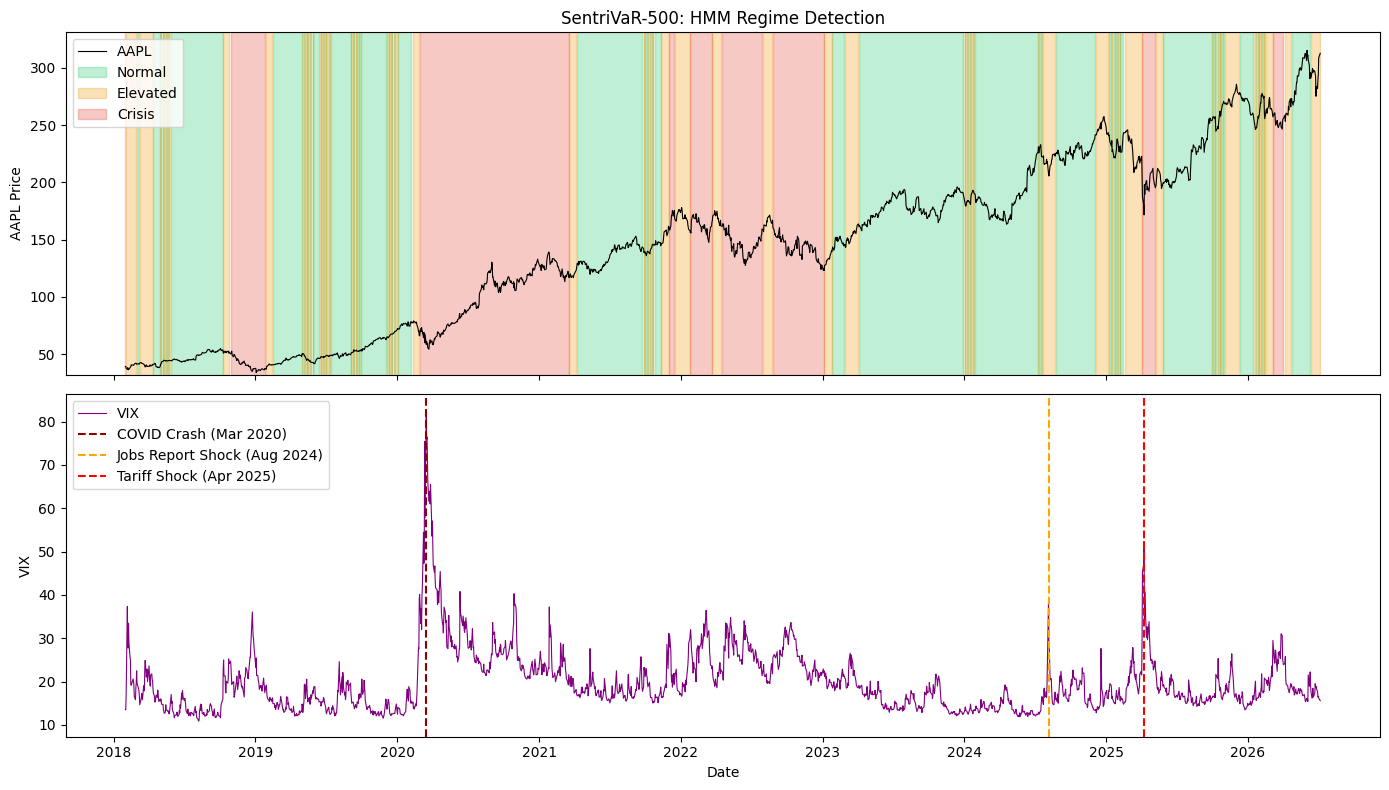

저장 완료: regime_detection_final.png


In [3]:
# 시각화 함수로 정리
def plot_regimes(df, macro_daily, state_series, dates):
    colors = {0: "#2ecc71", 1: "#f39c12", 2: "#e74c3c"}
    labels = {0: "Normal", 1: "Elevated", 2: "Crisis"}

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # 주가 + 국면 배경색
    aapl_price = df["AAPL"].reindex(dates)
    ax1.plot(dates, aapl_price, color="black", linewidth=0.8, label="AAPL", zorder=3)

    y_min = aapl_price.min() * 0.95
    y_max = aapl_price.max() * 1.05

    for state, color in colors.items():
        mask = state_series == state
        ax1.fill_between(dates, y_min, y_max,
                         where=mask.values, alpha=0.3,
                         color=color, label=labels[state])

    ax1.set_ylim(y_min, y_max)
    ax1.set_ylabel("AAPL Price")
    ax1.set_title("SentriVaR-500: HMM Regime Detection")
    ax1.legend(loc="upper left")

    # VIX + 케이스 스터디 이벤트
    ax2.plot(dates, macro_daily["VIX"].reindex(dates),
             color="purple", linewidth=0.8, label="VIX")
    ax2.axvline(pd.Timestamp("2020-03-16"), color="darkred",
                linestyle="--", linewidth=1.5, label="COVID Crash (Mar 2020)")
    ax2.axvline(pd.Timestamp("2024-08-05"), color="orange",
                linestyle="--", linewidth=1.5, label="Jobs Report Shock (Aug 2024)")
    ax2.axvline(pd.Timestamp("2025-04-07"), color="red",
                linestyle="--", linewidth=1.5, label="Tariff Shock (Apr 2025)")

    ax2.set_ylabel("VIX")
    ax2.set_xlabel("Date")
    ax2.legend(loc="upper left")

    plt.tight_layout()
    plt.savefig(os.path.expanduser("~/Desktop/SentriVaR-500/data/regime_detection_final.png"), dpi=150)
    plt.show()
    print("저장 완료: regime_detection_final.png")

plot_regimes(df, macro_daily, state_series, dates)

In [4]:
# 국면 데이터 저장
regime_df = pd.DataFrame({
    "date": dates,
    "regime": state_series.values,
    "regime_label": state_series.map(labels).values
})
regime_df.to_csv(f"{data_path}/regime_states.csv", index=False)

print("저장 완료: regime_states.csv")
print("\n국면별 날짜 수:")
print(regime_df["regime_label"].value_counts())

저장 완료: regime_states.csv

국면별 날짜 수:
regime_label
Normal      1055
Crisis       577
Elevated     470
Name: count, dtype: int64


In [5]:
# 국면별 평균 지표 확인 (왜 Crisis가 많은지 파악)
vix_aligned = macro_daily["VIX"].reindex(dates)
ret_aligned = returns["AAPL"].reindex(dates)
vol_aligned = returns["AAPL"].rolling(20).std().reindex(dates)

for state, label in labels.items():
    mask = state_series == state
    print(f"\n{label} ({mask.sum()}일)")
    print(f"  평균 VIX:      {vix_aligned[mask].mean():.1f}")
    print(f"  평균 수익률:   {ret_aligned[mask].mean():.4f}")
    print(f"  평균 변동성:   {vol_aligned[mask].mean():.4f}")


Normal (1055일)
  평균 VIX:      15.8
  평균 수익률:   0.0016
  평균 변동성:   0.0133

Elevated (470일)
  평균 VIX:      19.0
  평균 수익률:   0.0011
  평균 변동성:   0.0165

Crisis (577일)
  평균 VIX:      27.8
  평균 수익률:   0.0003
  평균 변동성:   0.0256


In [6]:
from sklearn.preprocessing import StandardScaler

# 피처 스케일링 적용 후 HMM 재학습
def train_hmm_scaled(returns, macro_daily, ticker="AAPL", n_components=3, smooth_window=20):
    # 입력 피처 구성
    hmm_data = returns[[ticker]].copy()
    hmm_data["volatility"] = returns[ticker].rolling(20).std()
    hmm_data = hmm_data.join(macro_daily["VIX"]).dropna()
    dates = hmm_data.index

    # 스케일링 (각 피처를 평균 0, 표준편차 1로 정규화)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(hmm_data.values)

    # HMM 학습
    model = hmm.GaussianHMM(n_components=n_components,
                             covariance_type="full",
                             n_iter=200,
                             random_state=42)
    model.fit(X_scaled)
    states = model.predict(X_scaled)

    # Smoothing
    smoothed = uniform_filter1d(states.astype(float), size=smooth_window)
    smoothed = np.round(smoothed).astype(int)
    state_series = pd.Series(smoothed, index=dates)

    # VIX 기준 자동 라벨링
    vix_aligned = macro_daily["VIX"].reindex(dates)
    state_vix_means = {s: vix_aligned[state_series == s].mean() for s in range(n_components)}
    sorted_states = sorted(state_vix_means, key=state_vix_means.get)
    label_map = {sorted_states[0]: 0, sorted_states[1]: 1, sorted_states[2]: 2}
    state_series = state_series.map(label_map)

    return state_series, dates, model, scaler

# 재학습
state_series, dates, hmm_model, scaler = train_hmm_scaled(returns, macro_daily)

# 국면 비율 확인
print("국면 비율 (스케일링 적용 후):")
for state, label in labels.items():
    ratio = (state_series == state).mean() * 100
    print(f"  {label}: {ratio:.1f}%")

국면 비율 (스케일링 적용 후):
  Normal: 52.0%
  Elevated: 21.6%
  Crisis: 26.5%


In [7]:
# 피처 추가: 국채 스프레드 포함
def train_hmm_v2(returns, macro_daily, ticker="AAPL", n_components=3, smooth_window=30):
    # 입력 피처: 수익률 + 20일 변동성 + VIX + 국채 스프레드
    hmm_data = returns[[ticker]].copy()
    hmm_data["volatility"] = returns[ticker].rolling(20).std()
    hmm_data = hmm_data.join(macro_daily[["VIX", "Spread"]]).dropna()
    dates = hmm_data.index

    # 스케일링
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(hmm_data.values)

    # HMM 학습
    model = hmm.GaussianHMM(n_components=n_components,
                             covariance_type="full",
                             n_iter=200,
                             random_state=42)
    model.fit(X_scaled)
    states = model.predict(X_scaled)

    # Smoothing (30일로 늘림)
    smoothed = uniform_filter1d(states.astype(float), size=smooth_window)
    smoothed = np.round(smoothed).astype(int)
    state_series = pd.Series(smoothed, index=dates)

    # VIX 기준 자동 라벨링
    vix_aligned = macro_daily["VIX"].reindex(dates)
    state_vix_means = {s: vix_aligned[state_series == s].mean() for s in range(n_components)}
    sorted_states = sorted(state_vix_means, key=state_vix_means.get)
    label_map = {sorted_states[0]: 0, sorted_states[1]: 1, sorted_states[2]: 2}
    state_series = state_series.map(label_map)

    return state_series, dates, model, scaler

# 재학습
state_series, dates, hmm_model, scaler = train_hmm_v2(returns, macro_daily)

print("국면 비율 (v2 - 스프레드 + smooth 30일):")
for state, label in labels.items():
    ratio = (state_series == state).mean() * 100
    print(f"  {label}: {ratio:.1f}%")

국면 비율 (v2 - 스프레드 + smooth 30일):
  Normal: 55.0%
  Elevated: 35.6%
  Crisis: 9.4%


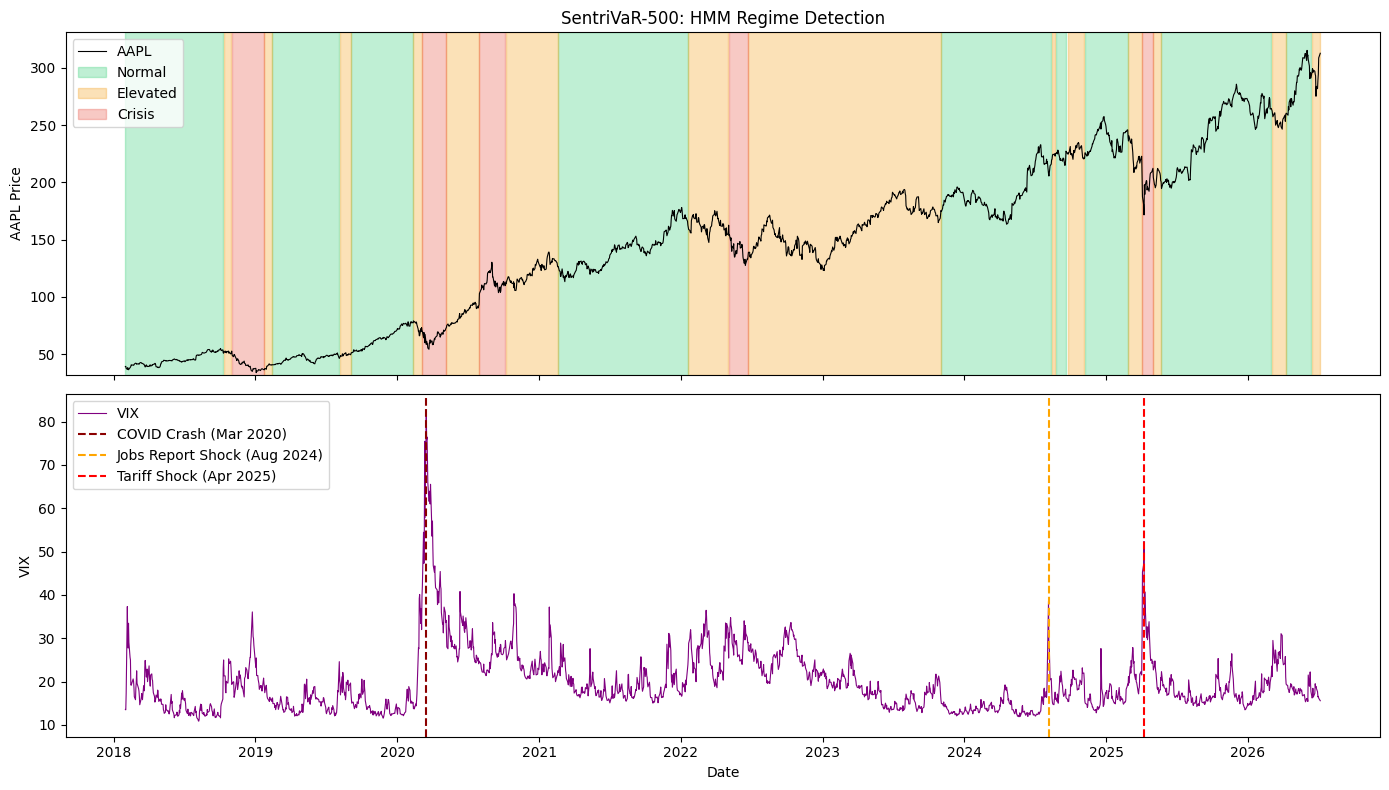

저장 완료: regime_detection_final.png


In [8]:
# v2 시각화로 확인
plot_regimes(df, macro_daily, state_series, dates)

In [9]:
# VIX 기준으로 초기 국면 직접 지정
def train_hmm_v3(returns, macro_daily, ticker="AAPL", smooth_window=30):
    hmm_data = returns[[ticker]].copy()
    hmm_data["volatility"] = returns[ticker].rolling(20).std()
    hmm_data = hmm_data.join(macro_daily[["VIX", "Spread"]]).dropna()
    dates = hmm_data.index

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(hmm_data.values)
    vix = macro_daily["VIX"].reindex(dates)

    model = hmm.GaussianHMM(n_components=3,
                             covariance_type="full",
                             n_iter=300,
                             random_state=42,
                             init_params="mc")  # s, t 제외 → 우리가 직접 지정
    
    # 초기값 직접 설정
    model.startprob_ = np.array([0.6, 0.3, 0.1])
    model.transmat_ = np.array([
        [0.95, 0.04, 0.01],
        [0.05, 0.90, 0.05],
        [0.02, 0.08, 0.90],
    ])

    model.fit(X_scaled)
    states = model.predict(X_scaled)

    smoothed = uniform_filter1d(states.astype(float), size=smooth_window)
    smoothed = np.round(smoothed).astype(int)
    state_series = pd.Series(smoothed, index=dates)

    state_vix_means = {s: vix[state_series == s].mean() for s in range(3)}
    sorted_states = sorted(state_vix_means, key=state_vix_means.get)
    label_map = {sorted_states[0]: 0, sorted_states[1]: 1, sorted_states[2]: 2}
    state_series = state_series.map(label_map)

    return state_series, dates, model, scaler

state_series, dates, hmm_model, scaler = train_hmm_v3(returns, macro_daily)

print("국면 비율 (v3):")
for state, label in labels.items():
    ratio = (state_series == state).mean() * 100
    print(f"  {label}: {ratio:.1f}%")

국면 비율 (v3):
  Normal: 42.9%
  Elevated: 29.9%
  Crisis: 27.3%


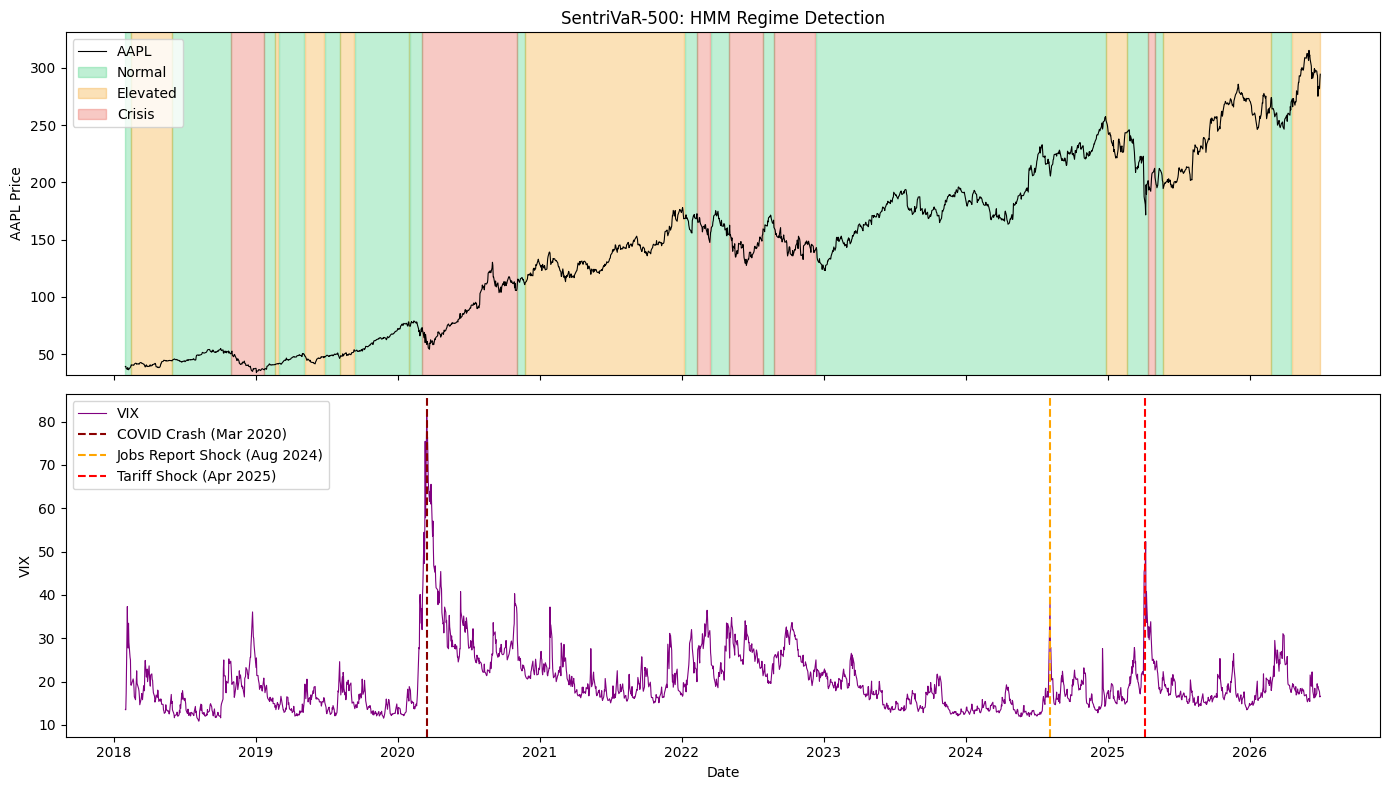

저장 완료: regime_detection_final.png


In [13]:
plot_regimes(df, macro_daily, state_series, dates)

In [14]:
# 최종 국면 데이터 저장
regime_df = pd.DataFrame({
    "date": dates,
    "regime": state_series.values,
    "regime_label": state_series.map(labels).values
})
regime_df.to_csv(f"{data_path}/regime_states.csv", index=False)
print("저장 완료: regime_states.csv (v3 최종)")

저장 완료: regime_states.csv (v3 최종)
